## AMDA product types: Catalogs, TimeTables, and Datasets

Beyond single time-series [`SpeasyVariable`s](../user/numpy.rst), AMDA also exposes richer, collection-like product types: `Catalog` (a list of `Event`s), `TimeTable` (a list of plain time intervals), and `Dataset` (a bundle of every `SpeasyVariable` belonging to one instrument). See [Data Providers](../user/data_providers.rst) for the general product-type overview.

## Only for Google Colab users

In [1]:
%pip install --upgrade ipympl speasy

/home/jeandet/.cache/uv/builds-v0/.tmp4TC5Ks/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except:
    print("Not running inside Google Collab")

Not running inside Google Collab


## For all users

In [3]:
import speasy as spz
%matplotlib inline
import matplotlib.pyplot as plt
import datetime

Legacy cache backup already present at /home/jeandet/.cache/speasy/Cache.diskcache.backup; skipping auto-migration. Move or remove it to retry.


Legacy cache backup already present at /home/jeandet/.local/share/speasy/index.diskcache.backup; skipping auto-migration. Move or remove it to retry.


You are using an incompatible proxy server http://sciqlop.lpp.polytechnique.fr/cache which is 0.13.5 while minimun required version is 0.14.0


### Catalogs

A `Catalog` behaves like a Python list of `Event` objects, plus some metadata:

In [4]:
first_catalog_index = spz.amda.list_catalogs()[0]
first_catalog = spz.amda.get_catalog(first_catalog_index)
first_catalog

<Catalog: model_regions_plasmas_mms_2019>

In [5]:
len(first_catalog), first_catalog[0]

(12691,
 <Event: 2019-01-01T00:00:04+00:00 -> 2019-01-01T00:24:04+00:00 | {'classes': '0'}>)

### TimeTables

A `TimeTable` behaves like a Python list of plain time intervals (`DateTimeRange`), with no event-specific metadata:

In [6]:
first_timetable_index = spz.amda.list_timetables()[0]
first_timetable = spz.amda.get_timetable(first_timetable_index)
first_timetable

<TimeTable: FTE_c1>

In [7]:
len(first_timetable), first_timetable[0]

(782, <DateTimeRange: 2001-02-02T16:39:57+00:00 -> 2001-02-02T16:39:58+00:00>)

### Datasets

A `Dataset` bundles every `SpeasyVariable` of one instrument dataset, indexable by variable name:

In [8]:
ace_dataset = spz.amda.get_dataset("ace-imf-all", datetime.datetime(2000, 1, 1), datetime.datetime(2000, 1, 2))
ace_dataset

<Dataset: final / prelim
        variables: ['|b|', 'b_gse', 'b_gsm']
        time range: <DateTimeRange: 2000-01-01T00:00:11+00:00 -> 2000-01-01T23:59:55+00:00>

In [9]:
# Index it like a dict of SpeasyVariable, or iterate over all its variables at once
ace_dataset["b_gse"].columns, sorted(list(ace_dataset))

(['bx', 'by', 'bz'], ['b_gse', 'b_gsm', '|b|'])

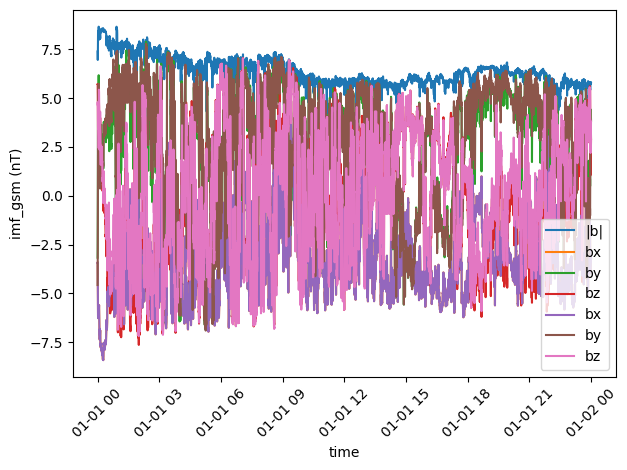

In [10]:
plt.figure()
ace_dataset.plot()
plt.tight_layout()
plt.show()

### Using a TimeTable to batch-fetch and analyze data

A `TimeTable` isn't just for browsing — pass it as `get_data()`'s time range to fetch one `SpeasyVariable` per interval in a single call. Here we use a public TimeTable of Magnetic Cloud intervals detected in `Wind`/MFI data:

In [11]:
amda_timetables = spz.inventories.tree.amda.TimeTables
amda_parameters = spz.inventories.tree.amda.Parameters
magnetic_clouds = spz.amda.get_timetable(amda_timetables.SharedTimeTables.SOLAR_WIND.Magnetic_Clouds)
print(magnetic_clouds.meta["description"])
len(magnetic_clouds)

Magnetic Clouds from WIND/MFI 1995-2007 -- Estimated start and end times from a magnetic field model [Lepping et al., 1990] which assumes that the field within the magnetic cloud is force free, i.e., so that the electrical current and the magnetic field are parallel and proportional in strength everywhere within its volume -- see http://lepmfi.gsfc.nasa.gov/mfi/mag_cloud_pub1.html ; 
        Historic: From old AMDA;
        Creation Date :  2013-11-22T13:52:50; 
 


106

In [12]:
# Fetch the solar wind thermal speed for the first 3 magnetic cloud intervals in one call
vth_per_cloud = spz.get_data(amda_parameters.Wind.SWE.wnd_swe_kp.wnd_swe_vth, magnetic_clouds[:3])
type(vth_per_cloud), len(vth_per_cloud)

(list, 3)

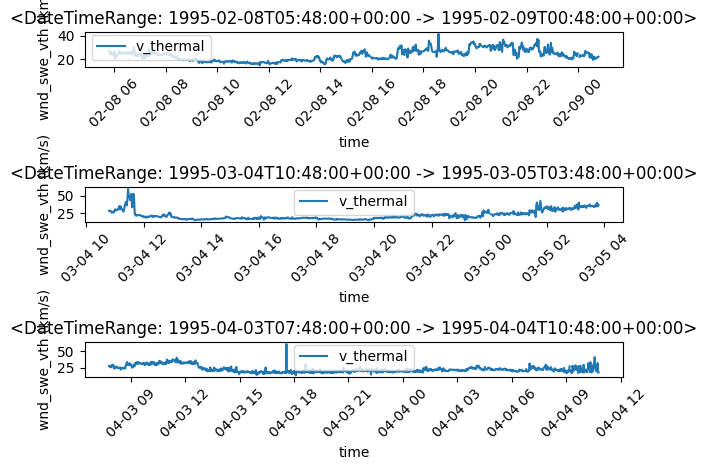

In [13]:
fig, axes = plt.subplots(len(vth_per_cloud), 1, sharex=False)
for ax, var, cloud in zip(axes, vth_per_cloud, magnetic_clouds[:3]):
    var.plot(ax=ax)
    ax.set_title(str(cloud))
plt.tight_layout()
plt.show()

The same pattern works with the *entire* TimeTable and several products at once — see `CompleteDemo.ipynb` for a larger version of this example.